In [3]:
import os
import regex as re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

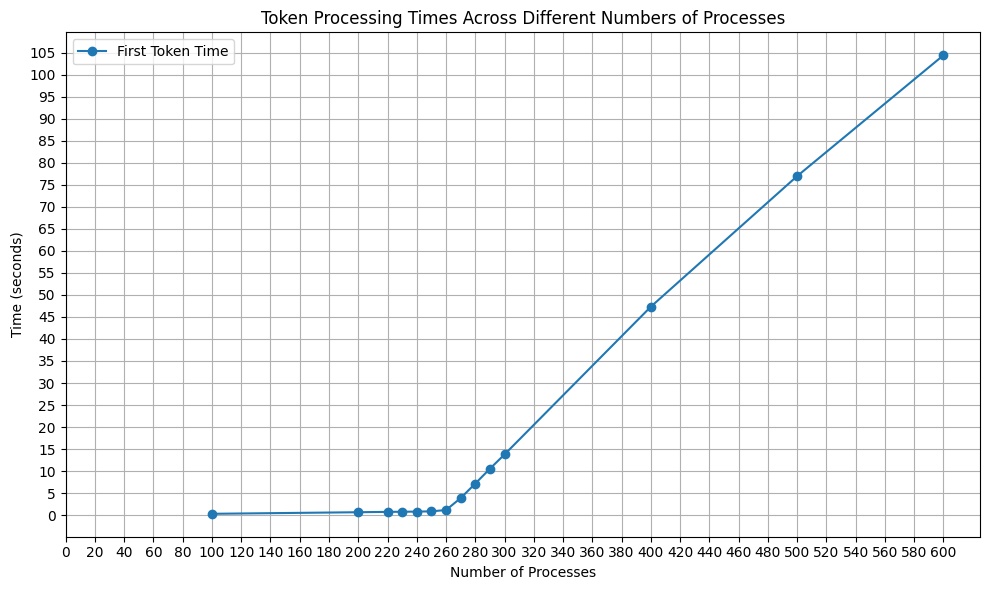

In [4]:
p_nums = []
plot_file_dir = "./results/gemma-2-27b-1r/"
plot_file_dir = "./results/llama-3-70b-1r/"
filenames = os.listdir(plot_file_dir)

for filename in filenames:
    if not filename.endswith(".csv"):
        continue
    p_num = re.findall(r"1gpu_(\d+)p_token_times.csv", filename)
    if p_num:
        p_nums.append(int(p_num[0]))

token_1_time = []
token_30_time = []
token_300_time = []
token_3000_time = []

for p_num in sorted(p_nums):
    # First Token Time,30 Tokens Time,300 Tokens Time,3000 Tokens Time,Final Token Time
    filename = os.path.join(plot_file_dir, f"1gpu_{p_num}p_token_times.csv")
    df = pd.read_csv(filename)

    times = df["First Token Time"].tolist()
    avg_time = sum(times) / len(times)
    token_1_time.append(avg_time)
    
    # times = df["30 Tokens Time"].tolist()
    # avg_time = sum(times) / len(times)
    # token_30_time.append(avg_time)

    # times = df["300 Tokens Time"].tolist()
    # avg_time = sum(times) / len(times)
    # token_300_time.append(avg_time)

    # # Fix the column name to match the actual CSV data
    # times = df["3000 Tokens Time"].tolist()
    # avg_time = sum(times) / len(times)
    # token_3000_time.append(avg_time)

# Plotting the results
plt.figure(figsize=(10, 6))

plt.plot(sorted(p_nums), token_1_time, marker='o', linestyle='-', label='First Token Time')
# plt.plot(sorted(p_nums), token_30_time, marker='o', linestyle='-', label='30 Tokens Time')
# plt.plot(sorted(p_nums), token_300_time, marker='o', linestyle='-', label='300 Tokens Time')
# plt.plot(sorted(p_nums), token_3000_time, marker='o', linestyle='-', label='3000 Tokens Time')

plt.title('Token Processing Times Across Different Numbers of Processes')
plt.xlabel('Number of Processes')
plt.ylabel('Time (seconds)')
plt.yticks(np.arange(0, max(token_1_time) + 5, 5))
plt.xticks(np.arange(0, 600 + 10, 20))
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()